# 01 Titanic EDA

Titanic 데이터를 불러오고, 데이터 분석을 시작하기 전에 기본 구조를 확인한다.

## 1. Import

`pandas`는 표 형태 데이터를 다루기 위한 Python 라이브러리다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. 데이터 불러오기

`read_csv()`는 CSV 파일을 DataFrame으로 읽어온다.

In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. 데이터 크기 확인

`shape`은 행과 열의 개수를 알려준다.

In [3]:
df.shape

(891, 12)

## 4. 컬럼과 데이터 타입 확인

`info()`는 컬럼명, 결측치가 아닌 값의 개수, 데이터 타입을 보여준다.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 5. 기본 통계 확인

`describe()`는 숫자형 컬럼의 평균, 표준편차, 최솟값, 최댓값 등을 보여준다.

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. 결측치 확인

`isna()`는 값이 비어 있는지 확인하고, `sum()`을 붙이면 컬럼별 결측치 개수를 볼 수 있다.

In [6]:
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## 7. 첫 인사이트

아래 셀을 실행한 뒤, 눈에 보이는 특징을 직접 적어본다.

- 전체 데이터는 몇 행, 몇 열인가?
- 어떤 컬럼에 결측치가 많은가?
- 숫자형 컬럼 중 눈에 띄는 값은 무엇인가?

## 첫 인사이트

- 전체 데이터는 891행, 12열이다.
- 승객 한 명당 하나의 행으로 구성되어 있다.
- `Survived` 컬럼은 생존 여부를 나타낸다. 0은 사망, 1은 생존이다.
- 전체 생존율은 약 38.4%로, 생존하지 못한 승객이 더 많다.
- `Cabin` 컬럼은 결측치가 687개로 매우 많아서 바로 분석에 쓰기 어렵다.
- `Age` 컬럼도 결측치가 177개 있어서 나이 분석 전 처리 방법을 고민해야 한다.
- `Embarked` 컬럼은 결측치가 2개뿐이라 간단히 처리할 수 있을 것 같다.
- 숫자형 컬럼 중 `Fare`는 최댓값이 평균보다 훨씬 커서 비싼 요금을 낸 승객이 일부 있는 것으로 보인다.

## 8. 성별에 따른 생존율

`groupby()`로 성별을 기준으로 데이터를 묶고, `Survived`의 평균을 계산하면 성별별 생존율을 확인할 수 있다.

`Survived`는 0 또는 1이기 때문에 평균을 내면 생존한 사람의 비율이 된다.

In [8]:
sex_survival = df.groupby("Sex")["Survived"].agg(["count", "sum", "mean"])
sex_survival

,count,sum,mean
Sex,,,
female,314,233,0.742038
male,577,109,0.188908


`count`는 성별별 승객 수, `sum`은 생존자 수, `mean`은 생존율이다.

In [9]:
sex_survival_rate = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
sex_survival_rate

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## 성별 생존율 인사이트

- 여성 승객의 생존율은 약 74.2%다.
- 남성 승객의 생존율은 약 18.9%다.
- 여성 승객의 생존율이 남성 승객보다 훨씬 높다.
- Titanic 데이터에서는 성별이 생존 여부와 강하게 관련되어 보인다.

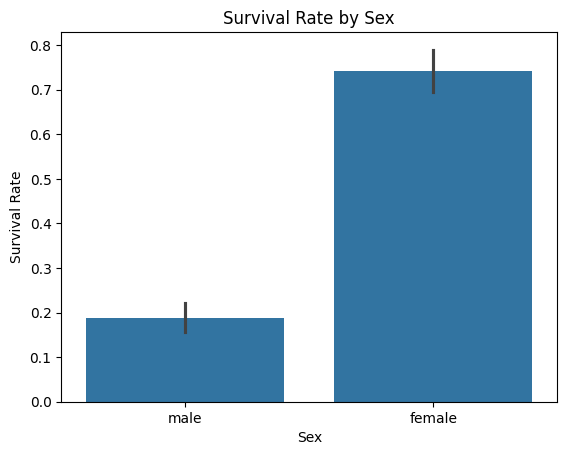

In [10]:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

## 9. 객실 등급에 따른 생존율

`Pclass`는 승객의 객실 등급을 나타낸다.

- `1`: 1등석
- `2`: 2등석
- `3`: 3등석

In [ ]:
pclass_survival = df.groupby("Pclass")["Survived"].agg(["count", "sum", "mean"])
pclass_survival

`Pclass`별 생존율을 보기 쉽게 정렬해서 확인한다.

In [ ]:
pclass_survival_rate = df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)
pclass_survival_rate

## 객실 등급 생존율 인사이트

- 1등석 승객의 생존율은 약 63.0%다.
- 2등석 승객의 생존율은 약 47.3%다.
- 3등석 승객의 생존율은 약 24.2%다.
- 객실 등급이 높을수록 생존율도 높게 나타난다.
- `Pclass`도 생존 여부와 관련이 큰 컬럼으로 보인다.

In [ ]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()